In [65]:
import pandas as pd

In [66]:
df = pd.read_csv("./csv/clear_data.csv")
df

,Country,ISO3,Year,Population,Population Growth,Growth Rate (%),Decade
0,Afghanistan,AFG,1960,8996973,485782.982759,2.505003,1960s
1,Afghanistan,AFG,1961,9169410,172437.000000,1.916611,1960s
2,Afghanistan,AFG,1962,9351441,182031.000000,1.985199,1960s
3,Afghanistan,AFG,1963,9543205,191764.000000,2.050636,1960s
4,Afghanistan,AFG,1964,9744781,201576.000000,2.112246,1960s
...,...,...,...,...,...,...,...
15404,Zimbabwe,ZWE,2014,13586681,236325.000000,1.770178,2010s
15405,Zimbabwe,ZWE,2015,13814629,227948.000000,1.677731,2010s
15406,Zimbabwe,ZWE,2016,14030390,215761.000000,1.561830,2010s
15407,Zimbabwe,ZWE,2017,14236745,206355.000000,1.470772,2010s


In [67]:

idx_min_by_country = df.groupby("Country")["Growth Rate (%)"].idxmin()
idx_min_by_country

Country
Afghanistan              23
Albania                 100
Algeria                 160
American Samoa          225
Andorra                 289
                      ...  
West Bank and Gaza    15171
World                 15231
Yemen, Rep.           15233
Zambia                15324
Zimbabwe              15393
Name: Growth Rate (%), Length: 263, dtype: int64

In [68]:
years_of_min = df.loc[idx_min_by_country, ["Country", "Year"]]
years_of_min

,Country,Year
23,Afghanistan,1983
100,Albania,2001
160,Algeria,2002
225,American Samoa,2008
289,Andorra,2013
...,...,...
15171,West Bank and Gaza,2017
15231,World,2018
15233,"Yemen, Rep.",1961
15324,Zambia,1993


In [69]:
year_start = years_of_min["Year"].value_counts().idxmax()
year_start

np.int64(2018)

In [70]:
countries_with_loss_in_start_year = years_of_min.loc[years_of_min["Year"] == year_start, "Country"].to_list()

countries_with_loss_in_start_year

['Bangladesh',
 'Barbados',
 'Bolivia',
 'Brazil',
 'Brunei Darussalam',
 'Costa Rica',
 'Dominican Republic',
 'Early-demographic dividend',
 'Fragile and conflict affected situations',
 'France',
 'Guatemala',
 'Haiti',
 'Honduras',
 'IBRD only',
 'IDA & IBRD total',
 'IDA blend',
 'India',
 'Indonesia',
 'Italy',
 'Jamaica',
 'Japan',
 'Kenya',
 'Korea, Dem. People’s Rep.',
 'Latin America & Caribbean',
 'Latin America & Caribbean (excluding high income)',
 'Latin America & the Caribbean (IDA & IBRD countries)',
 'Liechtenstein',
 'Low & middle income',
 'Lower middle income',
 'Mauritius',
 'Mexico',
 'Middle East & North Africa',
 'Middle East & North Africa (IDA & IBRD countries)',
 'Middle East & North Africa (excluding high income)',
 'Middle income',
 'Moldova',
 'Myanmar',
 'Nauru',
 'Nicaragua',
 'Pakistan',
 'Panama',
 'Paraguay',
 'Philippines',
 'Puerto Rico',
 'San Marino',
 'Saudi Arabia',
 'South Asia',
 'South Asia (IDA & IBRD)',
 'Thailand',
 'United States',
 'Venez

In [71]:
if not countries_with_loss_in_start_year:
    raise ValueError("Нет ни одной страны, с которой можно было бы дальше работать")


In [72]:
raw_start = year_start - 10
raw_end = year_start + 10

In [73]:
sub_all_years = df.loc[df["Country"].isin(countries_with_loss_in_start_year), "Year"]
print(sub_all_years)

data_min_year = int(sub_all_years.min())
print(data_min_year)

data_max_year = int(sub_all_years.max())
print(data_max_year)

944      1960
945      1961
946      1962
947      1963
948      1964
         ... 
15227    2014
15228    2015
15229    2016
15230    2017
15231    2018
Name: Year, Length: 3068, dtype: int64
1960
2018


In [74]:
start_year = max(data_min_year, raw_start)
print(start_year)

end_year = min(data_max_year, raw_end)
print(end_year)

2008
2018


In [75]:
plot_df = df[df["Country"].isin(countries_with_loss_in_start_year) & (df["Year"].between(start_year, end_year))].copy()

In [76]:
plot_df = plot_df.pivot_table(index = "Year", columns="Country", values="Population")
plot_df

Country,Bangladesh,Barbados,Bolivia,Brazil,Brunei Darussalam,Costa Rica,Dominican Republic,Early-demographic dividend,Fragile and conflict affected situations,France,...,Philippines,Puerto Rico,San Marino,Saudi Arabia,South Asia,South Asia (IDA & IBRD),Thailand,United States,"Venezuela, RB",World
Year,,,,,,,,,,,,,,,,,,,,,
2008,144304167.0,279946.0,9721454.0,192030362.0,379421.0,4463125.0,9458075.0,2.820904e+09,588463731.0,64374984.0,...,90901965.0,3760866.0,30434.0,25888541.0,1.592011e+09,1.592011e+09,66530984.0,304093966.0,27635832.0,6.757887e+09
2009,145924797.0,281104.0,9884781.0,193886508.0,383906.0,4520740.0,9576737.0,2.864615e+09,603084255.0,64707040.0,...,92414158.0,3740410.0,30816.0,26630303.0,1.615610e+09,1.615610e+09,66866839.0,306771529.0,28031009.0,6.840592e+09
2010,147575430.0,282131.0,10048590.0,195713635.0,388646.0,4577378.0,9695121.0,2.908288e+09,618029522.0,65027507.0,...,93966780.0,3721525.0,31229.0,27421461.0,1.638793e+09,1.638793e+09,67195028.0,309321666.0,28439940.0,6.922947e+09
2011,149273778.0,282987.0,10212954.0,197514534.0,393688.0,4633086.0,9813210.0,2.951856e+09,633349420.0,65342780.0,...,95570047.0,3678732.0,31661.0,28267685.0,1.661534e+09,1.661534e+09,67518382.0,311556874.0,28888369.0,7.004011e+09
2012,151007807.0,283700.0,10377676.0,199287296.0,398989.0,4688000.0,9930911.0,2.994853e+09,649017914.0,65659809.0,...,97212638.0,3634488.0,32105.0,29155187.0,1.683747e+09,1.683747e+09,67835957.0,313830990.0,29362449.0,7.086994e+09
2013,152764676.0,284296.0,10542376.0,201035903.0,404421.0,4742107.0,10048224.0,3.037663e+09,664910214.0,65998687.0,...,98871552.0,3593077.0,32553.0,30052518.0,1.705772e+09,1.705772e+09,68144501.0,315993715.0,29783571.0,7.170962e+09
2014,154520167.0,284825.0,10706517.0,202763735.0,409769.0,4795396.0,10165178.0,3.080325e+09,680822851.0,66312067.0,...,100513138.0,3534874.0,32948.0,30916994.0,1.727641e+09,1.727641e+09,68438730.0,318301008.0,30045134.0,7.255654e+09
2015,156256276.0,285324.0,10869730.0,204471769.0,414907.0,4847804.0,10281680.0,3.122842e+09,696655368.0,66548272.0,...,102113212.0,3473166.0,33272.0,31717667.0,1.749417e+09,1.749417e+09,68714511.0,320635163.0,30081829.0,7.340548e+09
2016,157970840.0,285796.0,11031813.0,206163058.0,419800.0,4899345.0,10397743.0,3.165142e+09,712367454.0,66721256.0,...,103663927.0,3406495.0,33504.0,32442572.0,1.771167e+09,1.771167e+09,68971331.0,322941311.0,29846179.0,7.426103e+09


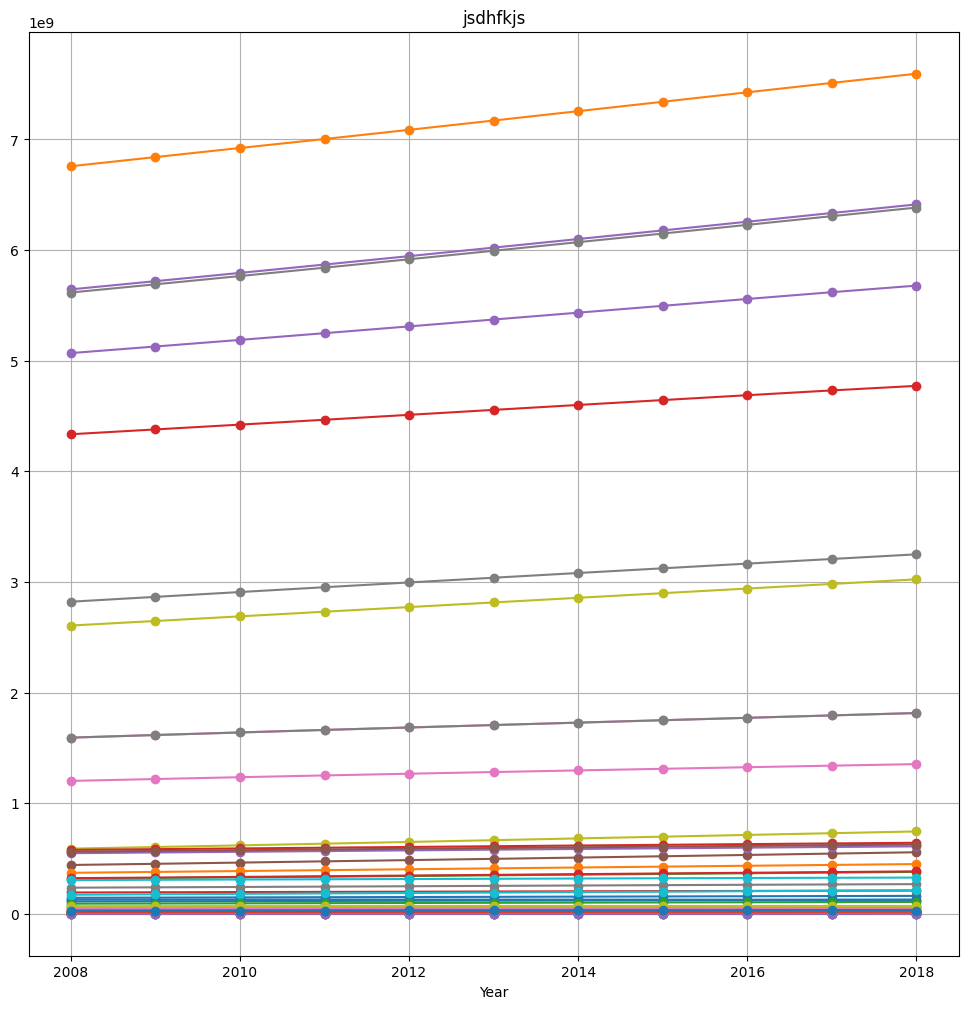

In [77]:
ax = plot_df.plot(
    figsize = (12,12),
    marker = "o",
    grid=True,
    title = "jsdhfkjs",
    legend = False
)

